# Phase 7 — Hero figure

One PNG that summarizes the project for the decision memo. Answers three questions at a glance: what's the current state, what are we recommending, what's the payoff.

Design principles:
- Single takeaway. Not every metric — just the money shot.
- Clear before/after.
- Numbers on the bars so it reads without a legend.
- Muted colors for status quo, bright color for the recommendation.

In [1]:
# Ensure the working directory is the project root, so paths like
# 'data/subscribers.csv' and 'mlruns/' resolve to one canonical location
# whether the notebook runs from notebooks/ or from the project root.
import os
from pathlib import Path
_here = Path.cwd()
if _here.name == 'notebooks':
    os.chdir(_here.parent)

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.loader import load_subscribers
from src.features.transforms import build_features
from src.models.train import prepare_features
from src.decisions.policy import (
    INTERVENTION_MENU, LTV_BY_TIER, PREMIUM_UPGRADE_CAP_PCT,
    pick_best_lever, apply_budget_cap, apply_premium_cap,
    summarize_policy, simulate_blanket_campaign,
)

FIG_DIR = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Compute both policies

In [2]:
raw = load_subscribers('data/subscribers.csv')
df = build_features(raw)
X, y = prepare_features(df)

with open('models/churn_model_v1.pkl', 'rb') as f:
    artifact = pickle.load(f)
model = artifact['production_model']
X = X[artifact['feature_names']]

p_churn = model.predict_proba(X)[:, 1]
ltv = df['plan_tier'].map(LTV_BY_TIER).values
tenure = df['tenure_months'].values

baseline = simulate_blanket_campaign(
    p_churn=p_churn, ltv=ltv, tenure_months=tenure,
    cost_per_user=5.0, target_month=11, uplift=0.15,
)

policy = pick_best_lever(p_churn, ltv, INTERVENTION_MENU)
policy = apply_budget_cap(policy, budget=200_000)
policy = apply_premium_cap(policy, n_total=len(policy), cap_pct=PREMIUM_UPGRADE_CAP_PCT)
targeted = summarize_policy(policy, targeted_only=True)

print(f'Blanket net EV:  ${baseline["net_expected_value"]:>10,.0f}')
print(f'Targeted net EV: ${targeted["net_expected_value"]:>10,.0f}')
print(f'Monthly swing:   ${targeted["net_expected_value"] - baseline["net_expected_value"]:>10,.0f}')

Blanket net EV:  $    -6,329
Targeted net EV: $     3,267
Monthly swing:   $     9,596


## Build the hero figure

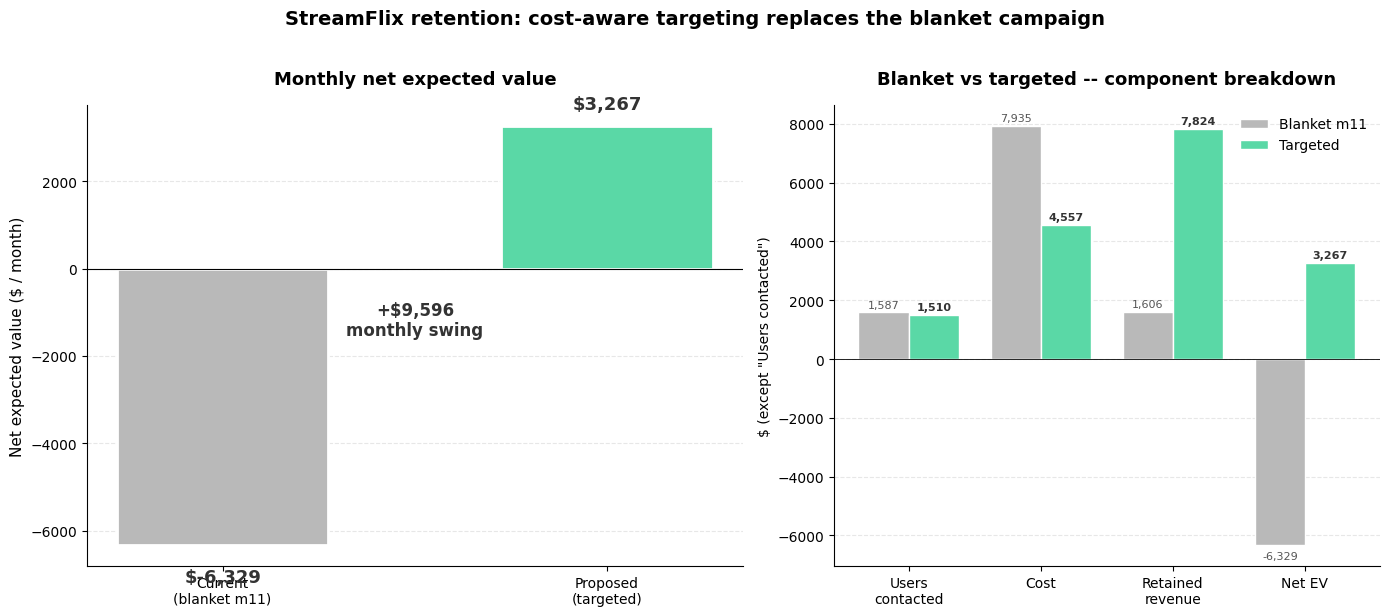

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6),
                                gridspec_kw={'width_ratios': [1.2, 1]})

# LEFT: net EV comparison
policies = ['Current\n(blanket m11)', 'Proposed\n(targeted)']
net_evs = [baseline['net_expected_value'], targeted['net_expected_value']]
colors = ['#B9B9B9', '#5AD8A6']
bars = ax1.bar(policies, net_evs, color=colors, edgecolor='white', width=0.55, linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8)
ax1.set_ylabel('Net expected value ($ / month)', fontsize=11)
ax1.set_title('Monthly net expected value', fontweight='bold', fontsize=13, pad=15)
for bar, val in zip(bars, net_evs):
    y_pos = val + (max(net_evs) - min(net_evs)) * 0.04 * (1 if val >= 0 else -2.2)
    ax1.text(bar.get_x() + bar.get_width() / 2, y_pos, f'${val:,.0f}',
             ha='center', fontsize=13, fontweight='bold', color='#333333')

swing = targeted['net_expected_value'] - baseline['net_expected_value']
ax1.annotate(f'+${swing:,.0f}\nmonthly swing',
             xy=(1, targeted['net_expected_value']),
             xytext=(0.5, (baseline['net_expected_value'] + targeted['net_expected_value']) / 2),
             ha='center', fontsize=12, fontweight='bold', color='#333333')
ax1.grid(axis='y', linestyle='--', alpha=0.3)
ax1.set_axisbelow(True)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# RIGHT: component breakdown
metrics = ['Users\ncontacted', 'Cost', 'Retained\nrevenue', 'Net EV']
blanket_vals = [baseline['n_targeted'], baseline['total_cost'],
                baseline['expected_retained_revenue'], baseline['net_expected_value']]
targeted_vals = [targeted['n_targeted'], targeted['total_cost'],
                 targeted['expected_retained_revenue'], targeted['net_expected_value']]
x_pos = np.arange(len(metrics))
width = 0.38

bars1 = ax2.bar(x_pos - width / 2, blanket_vals, width,
                label='Blanket m11', color='#B9B9B9', edgecolor='white')
bars2 = ax2.bar(x_pos + width / 2, targeted_vals, width,
                label='Targeted', color='#5AD8A6', edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.6)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(metrics, fontsize=10)
ax2.set_ylabel('$ (except "Users contacted")', fontsize=10)
ax2.set_title('Blanket vs targeted -- component breakdown', fontweight='bold', fontsize=13, pad=15)
ax2.legend(fontsize=10, loc='upper right', frameon=False)
ax2.grid(axis='y', linestyle='--', alpha=0.3)
ax2.set_axisbelow(True)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

for b, v in zip(bars1, blanket_vals):
    ax2.text(b.get_x() + b.get_width()/2,
             v + (max(blanket_vals + targeted_vals) * 0.02
                  if v >= 0 else max(blanket_vals + targeted_vals) * -0.06),
             f'{v:,.0f}', ha='center', fontsize=8, color='#555555')
for b, v in zip(bars2, targeted_vals):
    ax2.text(b.get_x() + b.get_width()/2,
             v + (max(blanket_vals + targeted_vals) * 0.02
                  if v >= 0 else max(blanket_vals + targeted_vals) * -0.06),
             f'{v:,.0f}', ha='center', fontsize=8, color='#333333', fontweight='bold')

plt.suptitle('StreamFlix retention: cost-aware targeting replaces the blanket campaign',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / '07_hero_summary.png', dpi=160, bbox_inches='tight')
plt.show()

## What this chart says

**Left panel.** Current blanket campaign runs a $6.3k monthly loss. Targeted policy delivers +$3.3k. Swing: **+$9.6k / month**.

**Right panel.** Component breakdown. Targeted policy contacts slightly fewer users (1,510 vs 1,587), spends 43% less ($4.5k vs $7.9k), but drives ~5× the expected retained revenue.

Full analysis: [`06_decision_rule.ipynb`](./06_decision_rule.ipynb). Decision memo: [`reports/decision_memo.md`](../reports/decision_memo.md).